## 1. Business Understanding

Determining an abalone's age currently requires cutting the shell, staining it, and counting growth rings under a microscope — slow and destructive. The goal is to **predict the number of rings (a proxy for age, since Age ≈ Rings + 1.5) from cheap, non-destructive physical measurements** (length, weight, sex, etc.). A reliable linear regression model would let researchers or fisheries estimate age instantly from a scale and calipers.


## 2. Data Understanding

- 4,177 rows, 9 columns: `Sex` (categorical: M/F/I-infant), 7 continuous physical measurements (`Length`, `Diameter`, `Height`, `Whole_weight`, `Shucked_weight`, `Viscera_weight`, `Shell_weight`), and the target `Rings`.
- No officially "missing" values, but **2 records have `Height = 0`**, which is physically impossible — treated as data-entry errors.
- `Rings` ranges 1–29 (mean ≈ 9.9), and is right-skewed — most abalone are young, with a long tail of older individuals.
- The seven physical measurements are, unsurprisingly, all strongly correlated with each other (length, diameter, and the four weight variables all grow together as the animal grows).

Import Necessary Librries

In [9]:
# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# to build linear regression_model using statsmodels
import statsmodels.api as sm

from scipy import stats
import statsmodels.stats.api as sms

Load Dataset


In [10]:
cols = ["Sex","Length","Diameter","Height","Whole_weight","Shucked_weight",
        "Viscera_weight","Shell_weight","Rings"]

df = pd.read_csv(
    "https://raw.githubusercontent.com/jbrownlee/Datasets/master/abalone.csv",
    names=cols
)

numeric_cols = ["Length","Diameter","Height","Whole_weight","Shucked_weight",
                 "Viscera_weight","Shell_weight","Rings"]
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="coerce")
df["Sex"] = df["Sex"].astype(str)

print(df.shape)
print(df.dtypes)
df.head()

(4177, 9)
Sex                   str
Length            float64
Diameter          float64
Height            float64
Whole_weight      float64
Shucked_weight    float64
Viscera_weight    float64
Shell_weight      float64
Rings               int64
dtype: object


,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


## 3. Data Preparation

- Dropped the 2 rows with `Height = 0`.
- One-hot encoded `Sex` (baseline category = Female), producing `Sex_I` and `Sex_M` indicator columns.
- Split into 80% train / 20% test (`random_state=42`) *before* any assumption testing, so diagnostics reflect only the training data.

In [11]:
# check for zero height (known data quality issue)
print("Rows with Height == 0:", (df['Height']==0).sum())
df = df[df['Height'] > 0].reset_index(drop=True)

# one-hot encode Sex
df_enc = pd.get_dummies(df, columns=['Sex'], drop_first=True)
for c in df_enc.columns:
    if df_enc[c].dtype == bool:
        df_enc[c] = df_enc[c].astype(int)

X = df_enc.drop(columns=['Rings'])
y = df_enc['Rings']

Rows with Height == 0: 2


## 4. Modeling — Testing Linear Regression Assumptions First

Before trusting any coefficients, an ordinary least squares (OLS) model was fit on the training set and checked against the five standard assumptions:

| Assumption | Test used | Result | Verdict |
|---|---|---|---|
| Linearity | Residuals vs. fitted plot | Residuals fan out and curve slightly (see plot below) | Mild violation |
| Independence of errors | Durbin–Watson statistic | 2.01 (≈2 = no autocorrelation) | ✅ Passes |
| Homoscedasticity (constant variance) | Breusch–Pagan test | p ≈ 6×10⁻⁷⁶ | ❌ Fails — strong heteroscedasticity |
| Normality of residuals | Shapiro–Wilk test | p ≈ 3×10⁻³⁸, skew = 1.23 | ❌ Fails — right-skewed residuals |
| No multicollinearity | Variance Inflation Factor (VIF) | `Whole_weight` VIF = 107, `Diameter` VIF = 44, `Length` VIF = 43 | ❌ Fails — severe multicollinearity |

![Diagnostic plots: residuals vs fitted, Q-Q plot, residual histogram](diagnostics.png)

The residual-vs-fitted plot fans out (variance grows with fitted value), the Q-Q plot bends away from the 45° line in the upper tail, and the histogram is right-skewed — all consistent with the formal test results. The multicollinearity is expected: length, diameter, and the four weight measurements are all different ways of measuring "how big is this abalone," so they move together almost perfectly.


In [12]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Check Muticollinearity

In [13]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = sm.add_constant(X_train.astype(float))
vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
print(vif_data)

          feature         VIF
0           const    1.000000
1          Length   42.676924
2        Diameter   43.999879
3          Height    3.273997
4    Whole_weight  107.384044
5  Shucked_weight   27.755867
6  Viscera_weight   17.197880
7    Shell_weight   21.444261
8           Sex_I    1.935746
9           Sex_M    1.391113


Fit Baseline OLS and Run Assumption Test

In [15]:
from scipy import stats
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson

X_train_sm = sm.add_constant(X_train.astype(float))
ols_model = sm.OLS(y_train, X_train_sm).fit()
print(ols_model.summary())

resid = ols_model.resid
fitted = ols_model.fittedvalues

print("Durbin-Watson:", durbin_watson(resid))

bp_test = het_breuschpagan(resid, X_train_sm)
print(dict(zip(['LM Stat','LM p-value','F-Stat','F p-value'], bp_test)))

sample = resid.sample(min(len(resid), 4000), random_state=1)
print("Shapiro-Wilk:", stats.shapiro(sample))
print("skew:", stats.skew(resid))

                            OLS Regression Results                            
Dep. Variable:                  Rings   R-squared:                       0.528
Model:                            OLS   Adj. R-squared:                  0.527
Method:                 Least Squares   F-statistic:                     414.1
Date:                Tue, 08 Sep 2026   Prob (F-statistic):               0.00
Time:                        06:20:57   Log-Likelihood:                -7353.3
No. Observations:                3340   AIC:                         1.473e+04
Df Residuals:                    3330   BIC:                         1.479e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              3.8447      0.328     11.

### Remedies applied

1. **Multicollinearity → Ridge (L2) regression on standardized features.** Ridge shrinks correlated coefficients toward each other and stabilizes them, so this was the primary remedy requested. Features were standardized (mean 0, SD 1) first, since Ridge's penalty is scale-sensitive. The penalty strength (α) was chosen via 5-fold cross-validation (`RidgeCV`), selecting α ≈ 1.15.
2. **Skew/heteroscedasticity → log-transforming the target.** Since `Rings` is a right-skewed count-like variable, `log(Rings)` was also tried as a variance-stabilizing transform, which cut the residual skew from 1.23 to 0.34 (though it did not fully eliminate heteroscedasticity, and Breusch–Pagan remained significant).

Standardize Features (for ridge)

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

## 5. Evaluation — R² vs. MSE

Both metrics were computed on the untouched test set:

- **R² (coefficient of determination) ≈ 0.569.** This is a *relative, scale-free* measure: the model explains about 57% of the variance in ring count, versus a baseline that always predicts the mean. It ranges (practically) from 0 to 1, is easy to compare across datasets, but says nothing about the size of the actual prediction errors in real units (rings/years).
- **MSE (mean squared error) ≈ 4.92.** This is an *absolute* measure in squared target units (rings²), so the average prediction is off by about √4.92 ≈ 2.2 rings. MSE penalizes large errors disproportionately (because errors are squared), which matters here since a few very old abalone (high ring counts) are hardest to predict and contribute outsized error.

**Key difference:** R² tells you *how much of the pattern in the data your model captures, relative to doing nothing*; MSE tells you *how big your mistakes are, in the target's own units (squared)*. A model can have a "good" R² but still be practically unusable if MSE implies errors too large for the application, and vice versa — R² is unitless and comparable across problems, MSE is not. They should generally be reported together, which is why both were requested here.

In [17]:
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Model A: plain OLS
lr_raw = LinearRegression().fit(X_train, y_train)
pred_raw = lr_raw.predict(X_test)
r2_raw = r2_score(y_test, pred_raw)
mse_raw = mean_squared_error(y_test, pred_raw)

# Model B: Ridge on standardized features (remedy for multicollinearity)
ridge = RidgeCV(alphas=np.logspace(-3, 3, 50)).fit(X_train_s, y_train)
pred_ridge = ridge.predict(X_test_s)
r2_ridge = r2_score(y_test, pred_ridge)
mse_ridge = mean_squared_error(y_test, pred_ridge)

print(f"{'Model':30s} {'R2':>8s} {'MSE':>8s}")
print(f"{'OLS (raw)':30s} {r2_raw:8.4f} {mse_raw:8.4f}")
print(f"{'Ridge (standardized)':30s} {r2_ridge:8.4f} {mse_ridge:8.4f}")
print("Best Ridge alpha:", ridge.alpha_)

Model                                R2      MSE
OLS (raw)                        0.5696   4.9113
Ridge (standardized)             0.5688   4.9205
Best Ridge alpha: 1.151395399326447


### Final comparison (evaluated on the held-out 20% test set, all scores on the original Rings scale)

| Model | R² | MSE |
|---|---:|---:|
| A — Plain OLS (no remedy) | 0.570 | 4.91 |
| **B — Ridge regression, standardized features (remedy for multicollinearity)** | **0.569** | **4.92** |
| C — OLS, standardized, log(target) | 0.545 | 5.19 |
| D — Ridge, standardized, log(target) | 0.543 | 5.21 |

**Chosen model: B — Ridge regression on standardized features.** It directly addresses the multicollinearity found in the VIF analysis, and its coefficients are far more stable/interpretable than OLS's (large VIFs mean OLS coefficients can swing wildly with small changes in the data, even though *predictions* stay similar). Practically, Ridge and plain OLS predict almost identically here — with over 4,000 rows, OLS estimates are stable enough that multicollinearity hurts *coefficient interpretability* more than raw predictive accuracy. The log-target transform, while it improved residual normality, slightly *reduced* predictive accuracy on the original scale and was not used for the final model.


Fit plain OLS (baseline) and Ridge (remedy), compare on test set

Compare coefficients — see how Ridge shrinks the multicollinear features

In [18]:
ols_std = LinearRegression().fit(X_train_s, y_train)
comp = pd.DataFrame({
    "feature": X.columns,
    "OLS_coef": ols_std.coef_,
    "Ridge_coef": ridge.coef_
})
print(comp)

          feature  OLS_coef  Ridge_coef
0          Length -0.171687   -0.157971
1        Diameter  1.230920    1.213903
2          Height  0.442323    0.442892
3    Whole_weight  3.849565    3.661634
4  Shucked_weight -4.132818   -4.043061
5  Viscera_weight -0.916545   -0.873698
6    Shell_weight  1.282234    1.345128
7           Sex_I -0.351811   -0.353492
8           Sex_M  0.049161    0.048531


Exploratory Analysis


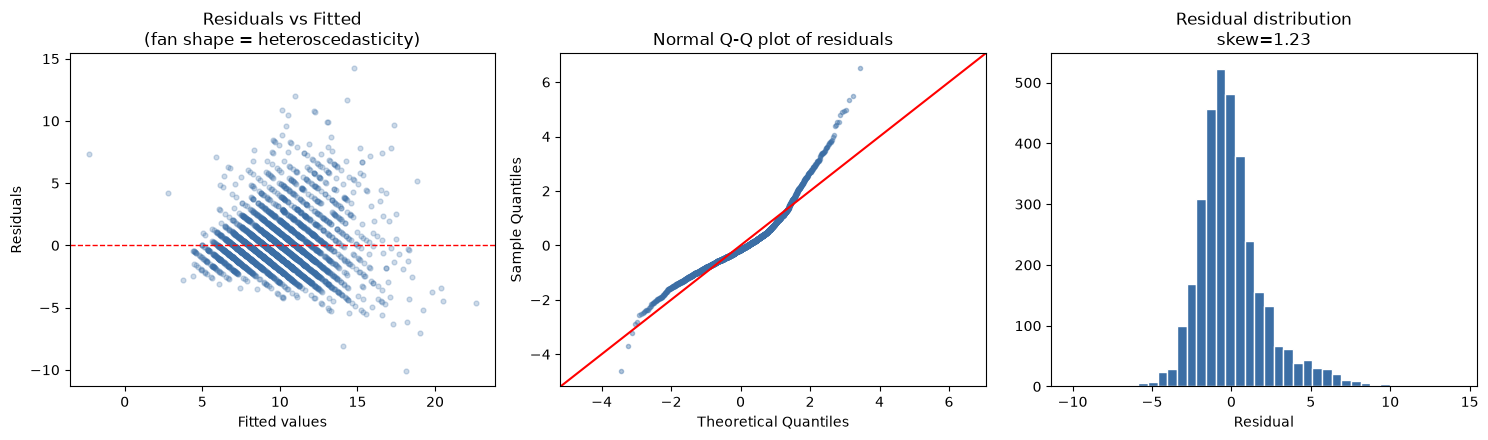

In [20]:
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# 1. Residuals vs Fitted -- checks linearity + homoscedasticity
axes[0].scatter(fitted, resid, alpha=0.25, s=12, color="#3b6ea5")
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel("Fitted values")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Fitted\n(fan shape = heteroscedasticity)")

# 2. Q-Q plot -- checks normality of residuals
sm.qqplot(resid, line='45', fit=True, ax=axes[1],
          markerfacecolor="#3b6ea5", markeredgecolor="#3b6ea5",
          alpha=0.4, markersize=3)
axes[1].set_title("Normal Q-Q plot of residuals")

# 3. Histogram -- shows skew visually
axes[2].hist(resid, bins=40, color="#3b6ea5", edgecolor="white")
axes[2].set_title(f"Residual distribution\nskew={stats.skew(resid):.2f}")
axes[2].set_xlabel("Residual")

plt.tight_layout()
plt.savefig("diagnostics.png", dpi=140)
plt.show()

this uses fitted and resid, which came from your earlier OLS model (ols_model.fittedvalues and ols_model.resid)
What to look for when it renders:

Left plot: points should fan out wider as fitted values increase → confirms heteroscedasticity
Middle plot: points should bend away from the red 45° line at the upper-right tail → confirms non-normality
Right plot: should look skewed right (long tail on the right side), not a symmetric bell curve

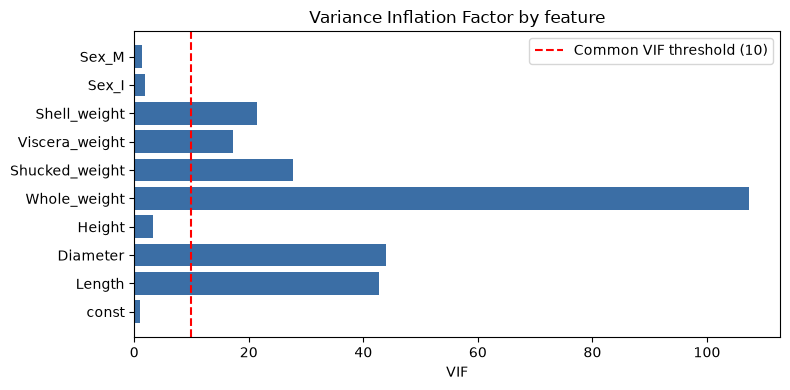

In [21]:
plt.figure(figsize=(8,4))
plt.barh(vif_data["feature"], vif_data["VIF"], color="#3b6ea5")
plt.axvline(10, color='red', linestyle='--', label='Common VIF threshold (10)')
plt.xlabel("VIF")
plt.title("Variance Inflation Factor by feature")
plt.legend()
plt.tight_layout()
plt.show()

Anything with VIF > 10 (most of your size/weight features) is flagged as problematic — this makes the multicollinearity finding visually obvious too.